# Concentrations Vertical Profiles

In [1]:
import cmocean.cm as cm
import copy
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.colors as mcolors
#
from shapely.geometry import Polygon, Point
from shapely.plotting import plot_polygon
from matplotlib.path import Path
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')

In [3]:
from Regions_functions_V2 import polygon_S1, polygon_lon_lat_S1

Obs

In [22]:
feb_2017_S4_15_28 = [4.4]
feb_2017_S4_15_47 = [155]
feb_2017_S4_15_99 = [55.6]
feb_2017_S4_15_153 = [2.2]	
feb_2017_S4_15_183 = [0.15]	
feb_2017_S4_15_209 = [26]
feb_2017_S4_15_depth = [6]
#
may_2017_S4_15_28 = [4.85, 3.15, 7.35, 12.1, 12.7, 5.79]
may_2017_S4_15_47 = [123, 79.7, 176, 336, 256, 133]
may_2017_S4_15_99 = [29.5, 20.2, 41.9, 75.5, 41.7, 32.2]
may_2017_S4_15_153 = [0.67, 0.48, 2.20, 1.49, 0.69, 0.69]	
may_2017_S4_15_183 = [0.15, 0.15, 0.17, 0.16, 0.17, 0.17]	
may_2017_S4_15_209 = [25.7, 25.4, 28.8, 27.7, 130, 28.6]
may_2017_S4_15_depth = [2, 25, 50, 75, 150, 300]
#
sep_2017_S4_15_28 = [1.29, 6.30, 1.83, 3.31, 2.74, 6.12]
sep_2017_S4_15_47 = [40.9, 216, 38.5, 84.8, 60.9, 186]
sep_2017_S4_15_99 = [9.68, 66.30, 9.79, 18.54, 13.02, 40.90]
sep_2017_S4_15_153 = [0.50, 1.38, 0.52, 0.50, 0.53, 0.83]	
sep_2017_S4_15_183 = [0.16, 0.15, 0.16, 0.16, 0.16, 0.15]	
sep_2017_S4_15_209 = [26.70, 25.76, 27.69, 26.58, 27.98, 87.36]
sep_2017_S4_15_depth = [2, 31, 57, 71, 145, 305]
#
jan_2018_S4_15_28 = [0.83, 1.27, 1.79, 1.46]
jan_2018_S4_15_47 = [19.4, 56.7, 61.2, 43.9]
jan_2018_S4_15_99 = [6.05, 26.5, 20.4, 14.2]	
jan_2018_S4_15_153 = [0.15, 1.43, 0.49, 0.43]	
jan_2018_S4_15_183 = [0.15, 0.15, 0.15, 0.06]	
jan_2018_S4_15_209 = [25.8, 87.1, 86.2, 35.2]
jan_2018_S4_15_depth = [26, 73, 147, 342]
#
apr_2018_S4_15_28 = [6.14, 3.04, 4.85, 2.58, 3.90, 5.34]
apr_2018_S4_15_47 = [261, 111, 182, 80.4, 134, 176]
apr_2018_S4_15_99 = [90.0, 35.8, 46.9, 29.0, 42.3, 54.7]
apr_2018_S4_15_153 = [3.76, 1.06, 1.42, 1.14, 1.12,	1.75]	
apr_2018_S4_15_183 = [0.16, 0.15, 0.15, 0.15, 0.15, 0.15]	
apr_2018_S4_15_209 = [26.6, 26.2, 26.2, 87.1, 26.0, 26.0]
apr_2018_S4_15_depth = [2, 24, 59, 73, 160, 307]
#
aug_2018_S4_15_28 = [5.86, 7.55, 7.36, 3.03, 5.17, 5.97]
aug_2018_S4_15_47 = [133, 228, 211, 82.3, 180, 244]
aug_2018_S4_15_99 = [50.7, 83.5, 85.5, 26.2, 69.1, 100]	
aug_2018_S4_15_153 = [2.33, 2.47, 2.94, 0.77, 2.02, 2.49]	
aug_2018_S4_15_183 = [0.16, 0.16, 0.16,	0.16, 0.23, 0.16]	
aug_2018_S4_15_209 = [91.38, 26.63, 90.02, 26.83, 39.94, 27.00]
aug_2018_S4_15_depth = [4, 26, 54, 70, 147, 294]

In [4]:
def volume_region_50m_bottom(polygon):
    mesh = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')
    volume = mesh['volume']
    mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')['tmask'][0]
    #
    depths = mesh['gdept_1d'][0] 
    depth_condition = depths >= 50
    # 
    depth_mask_3d = depth_condition.values[:, np.newaxis, np.newaxis]
    #    
    x = volume['x']  
    y = volume['y'] 
    #
    xx, yy = np.meshgrid(x, y)
    #
    # 2D Polygon Mask
    polygon_mask_2d = np.array([
        [polygon.contains(Point(xx[j, i], yy[j, i])) for i in range(len(x))]
        for j in range(len(y))
    ])

    # to 3D
    nz = volume.sizes['z']
    polygon_mask_3d = np.repeat(polygon_mask_2d[np.newaxis, :, :], nz, axis=0)

    # inside polygon  + in water + > 50 m
    combined_mask = (polygon_mask_3d & (mask.values == 1) & depth_mask_3d)

    # Applying mask
    mask_da = xr.DataArray(combined_mask, dims=volume.dims, coords=volume.coords)
    volume_in_polygon_water = volume.where(mask_da).sum().item()
    
    return volume_in_polygon_water

In [5]:
def get_binned_timeseries_multi(filenames, polygon_coords, 
                                z_var='z', lon_var='lon', lat_var='lat', status_var='status', 
                                target_status=None, step=10, cumulative=False):
    
    if isinstance(filenames, str):
        filenames = [filenames]
        
    poly_path = Path(polygon_coords)
    all_dfs = []
    
    for filename in filenames:
        timeseries_dict = {}
        
        with xr.open_dataset(filename) as data:
            z_vals = data[z_var].values
            lon_vals = data[lon_var].values
            lat_vals = data[lat_var].values
            
            n_obs = z_vals.shape[1] 
            
            if target_status is not None:
                status_vals = data[status_var].values
                if isinstance(target_status, (list, tuple, np.ndarray)):
                    status_mask = np.isin(status_vals, target_status)
                else:
                    status_mask = status_vals == target_status
            else:
                status_mask = np.ones_like(z_vals, dtype=bool)
            
            if not np.any(status_mask):
                all_dfs.append(pd.DataFrame())
                continue
                
            min_depth = np.nanmin(z_vals[status_mask])
            max_depth = np.nanmax(z_vals[status_mask])
            current_z = np.floor(min_depth / step) * step
            
            while current_z < max_depth:
                next_z = current_z + step
                bin_label = f"{int(current_z)}-{int(next_z)}"
                
                depth_mask = (z_vals >= current_z) & (z_vals < next_z)
                valid_mask = status_mask & depth_mask
                
                counts_per_time = np.zeros(n_obs, dtype=int)
                
                if np.any(valid_mask):
                    valid_lon = lon_vals[valid_mask]
                    valid_lat = lat_vals[valid_mask]
                    points = np.column_stack((valid_lon, valid_lat))
                    inside_poly = poly_path.contains_points(points)
                    
                    if np.any(inside_poly):
                        valid_obs_idx = np.where(valid_mask)[1]
                        inside_obs_idx = valid_obs_idx[inside_poly]
                        counts_per_time = np.bincount(inside_obs_idx, minlength=n_obs)
                
                timeseries_dict[bin_label] = counts_per_time
                current_z = next_z
                
        all_dfs.append(pd.DataFrame(timeseries_dict))
        
    if not all_dfs:
        return pd.DataFrame()
        
    if cumulative:
        combined_dfs = [all_dfs[0]]
        for i in range(1, len(all_dfs)):
            # Superimposes Year 1 (baseline release) onto every subsequent year
            current_total = all_dfs[i].add(all_dfs[0], fill_value=0)
            combined_dfs.append(current_total)
        final_df = pd.concat(combined_dfs, ignore_index=True)
    else:
        final_df = pd.concat(all_dfs, ignore_index=True)
        
    final_df = final_df.fillna(0)
    
    return final_df

In [6]:
filenames = [f'/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_{i}.nc' for i in range(1, 13)]

In [8]:
volume_S1 = volume_region_50m_bottom(polygon_S1)

In [14]:
conversion = (1/96) * (1/volume_S1)

In [ ]:
full_timeseries_S1_C = get_binned_timeseries_multi(filenames, polygon_lon_lat_S1, target_status = 2, cumulative = True)

In [46]:
first_year_timeseries_S1_C = get_binned_timeseries_multi(filenames[0], polygon_lon_lat_S1, target_status = 2, cumulative = True)

In [29]:
final_stats_C = pd.DataFrame({
    'Mean_Count': full_timeseries_S1_C.mean(),
    'Std_Dev': full_timeseries_S1_C.std()
})
final_stats_C.index.name = 'Depth_Bin'

In [47]:
first_stats_C = pd.DataFrame({
    'Mean_Count': first_year_timeseries_S1_C.mean(),
    'Std_Dev': first_year_timeseries_S1_C.std()
})
first_stats_C.index.name = 'Depth_Bin'

In [30]:
y_midpoints = np.array([np.mean([float(val) for val in bin_str.split('-')]) for bin_str in final_stats_C.index])

Text(0.5, 0, 'pg/kg (S4-1.5)')

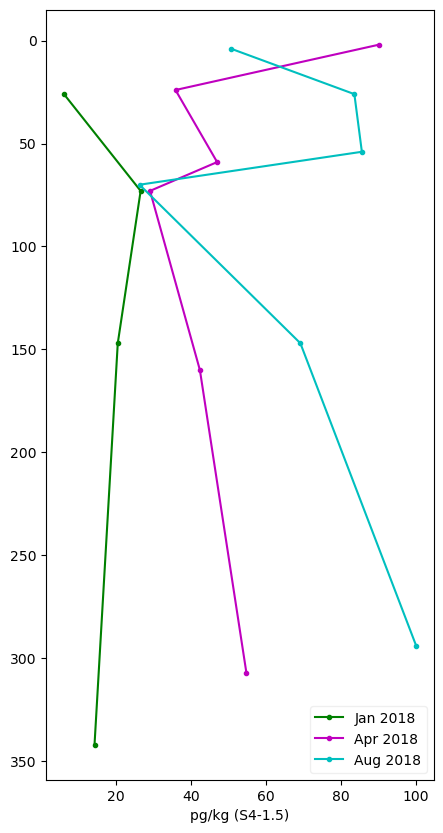

In [ ]:
fig, ax = plt.subplots(figsize = (5, 10))

ax.plot(feb_2017_S4_15_99, feb_2017_S4_15_depth, 'k.-', label = 'Feb 2017')
ax.plot(may_2017_S4_15_99, may_2017_S4_15_depth, 'r.-', label = 'May 2017')
ax.plot(sep_2017_S4_15_99, sep_2017_S4_15_depth, 'b.-', label = 'Sep 2017')
ax.plot(jan_2018_S4_15_99, jan_2018_S4_15_depth, 'g.-', label = 'Jan 2018')
ax.plot(apr_2018_S4_15_99, apr_2018_S4_15_depth, 'm.-', label = 'Apr 2018')
ax.plot(aug_2018_S4_15_99, aug_2018_S4_15_depth, 'c.-', label = 'Aug 2018')
ax.invert_yaxis()
ax.legend(loc = 'lower right', framealpha = .3)
ax.set_xlabel('pg/kg (S4-1.5)')



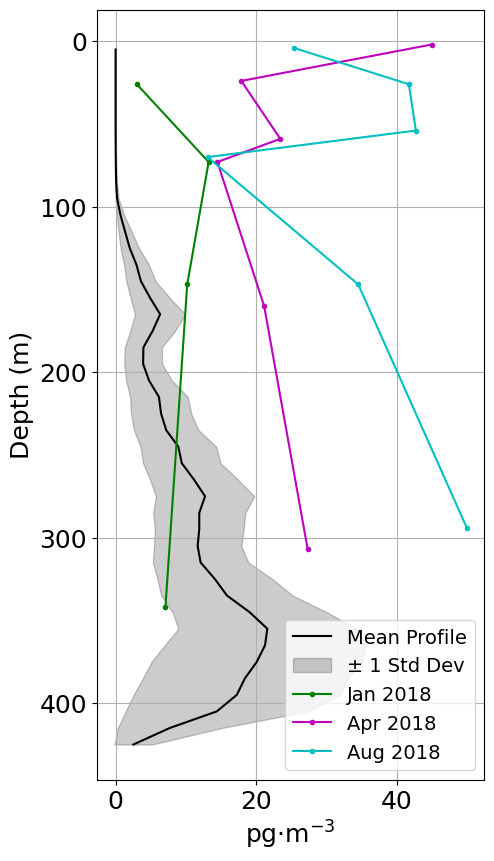

In [60]:
from scipy.ndimage import gaussian_filter1d
plt.rcParams.update({'font.size': 18})

fig, ax = plt.subplots(figsize=(5, 10))

mean_raw = final_stats_C['Mean_Count'] * conversion * 1e12
std_raw = final_stats_C['Std_Dev'] * conversion * 1e12
#
#
# increase or decrease the 'sigma' value for more or less smoothing
mean_smooth = gaussian_filter1d(mean_raw, sigma=1)
std_smooth = gaussian_filter1d(std_raw, sigma=1)
#
ax.plot(mean_smooth, y_midpoints, color='k', label='Mean Profile')

#
ax.fill_betweenx(
    y=y_midpoints,
    x1=mean_smooth - std_smooth,
    x2=mean_smooth + std_smooth,
    color='k',
    alpha=0.2, # Lower alpha makes it transparent
    label='± 1 Std Dev'
)
#
#ax.plot(feb_2017_S4_15_99, feb_2017_S4_15_depth, 'k.-', label = 'Feb 2017')
#ax.plot(may_2017_S4_15_99, may_2017_S4_15_depth, 'r.-', label = 'May 2017')
#ax.plot(sep_2017_S4_15_99, sep_2017_S4_15_depth, 'b.-', label = 'Sep 2017')
ax.plot(np.array(jan_2018_S4_15_99) / 2, jan_2018_S4_15_depth, 'g.-', label = 'Jan 2018')
ax.plot(np.array(apr_2018_S4_15_99) / 2, apr_2018_S4_15_depth, 'm.-', label = 'Apr 2018')
ax.plot(np.array(aug_2018_S4_15_99) / 2, aug_2018_S4_15_depth, 'c.-', label = 'Aug 2018')
#
ax.invert_yaxis()
ax.legend(loc = 'lower right', fontsize = 14)
ax.grid()
ax.set_ylabel('Depth (m)')
ax.set_xlabel(r'pg$\cdot$m$^{-3}$')

plt.show()